# CMA-ES run analysis

Summarizes each fit under `CMAES-results/<ts>/` from its own artifacts: `best.yaml` (tuned config),
`coeff.txt` (freed params + objective), `metrics.csv` (baseline→best RMSE **on the fit's training
data**), and `convergence.csv` (the trace). Independent test-set (paper Table II) evaluation — which
requires re-running `bem-model` on the hold-out with the identified coefficients — is out of scope
here and belongs in a separate notebook.

In [1]:
from pathlib import Path

import pandas as pd
import yaml
import matplotlib.pyplot as plt

NBEM = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "processed_data").exists())
RESULTS = NBEM / "CMAES-results"
DEFAULTS = {k: v for s in yaml.safe_load(open(NBEM / "processed_data/bem/params.yaml")).values() for k, v in s.items()}
pd.set_option("display.max_columns", None, "display.width", None)


def flatten_yaml(path):
    return {k: v for s in yaml.safe_load(open(path)).values() for k, v in s.items()}


def load_run(d):
    lines = [l.strip() for l in open(d / "coeff.txt") if l.strip()]
    return dict(
        coeffs=flatten_yaml(d / "best.yaml"),
        objective=lines[1],            # force-only / force+torque
        freed=lines[2:],               # params the fit actually moved
        metrics=pd.read_csv(d / "metrics.csv").iloc[0],
    )


RUNS = {d.name: load_run(d) for d in sorted(RESULTS.iterdir()) if d.is_dir()}
list(RUNS)

['2026-07-14-00-00-00', '2026-07-15-00-00-00', '2026-07-21-14-54-19']

## Coefficients

`default` = the canonical `REGISTRY` values (`processed_data/bem/params.yaml`); each `<ts>` row is a
run's `best.yaml`. `objective` (from `coeff.txt`) is `force-only` / `force+torque`; `freed` lists the
params the fit was allowed to move — everything else stays at `default`.

In [2]:
rows = {"default": {"objective": "—", "freed": "", **DEFAULTS}}
for ts, r in RUNS.items():
    rows[ts] = {"objective": r["objective"], "freed": ", ".join(r["freed"]), **r["coeffs"]}

coeff_df = pd.DataFrame(rows).T[["objective", "freed", *DEFAULTS]]
for c in DEFAULTS:
    coeff_df[c] = coeff_df[c].astype(float)
coeff_df

,objective,freed,lift_coefficient,drag_coefficient,hinge_spring_constant,lift_offset,hforce_scale,pitch,twist,chord_inner,chord_outer,radius,num_blades,air_density,thrust_scale,dx,dy,dz,horizontal_drag_coefficient,vertical_drag_coefficient,frontarea_x,frontarea_y,frontarea_z
default,—,,15.242140,13.548940,5.890000,0.000000,1.000000,21.770000,-11.0,0.017,0.007,0.06477,3.0,1.204,1.0,0.078,0.1,0.027,1.0,1.0,0.0054,0.009,0.006
2026-07-14-00-00-00,—,,15.242140,13.548940,5.890000,0.000000,1.000000,21.770000,-11.0,0.017,0.007,0.06477,3.0,1.204,1.0,0.078,0.1,0.027,1.0,1.0,0.0054,0.009,0.006
2026-07-15-00-00-00,force-only,"lift_coefficient, drag_coefficient",14.329000,14.454000,5.890000,0.000000,1.000000,21.770000,-11.0,0.017,0.007,0.06477,3.0,1.204,1.0,0.078,0.1,0.027,1.0,1.0,0.0054,0.009,0.006
2026-07-21-14-54-19,force-only,"lift_coefficient, drag_coefficient, hinge_spri...",4.846352,3.085872,1.729028,0.045578,2.651552,27.020107,-11.0,0.017,0.007,0.06477,3.0,1.204,1.0,0.078,0.1,0.027,1.0,1.0,0.0054,0.009,0.006


## Fit metrics

Each run's `best` force/torque RMSE (from `metrics.csv`), measured **on the run's own training data**
(the CSV `cmaes` was fit on, e.g. `subset_20k`) — the optimizer's own objective, not the independent
test-set Table II. The earliest-dated run is the **baseline** (default params, zero params freed), so
it doubles as the reference row here.

In [3]:
metrics_df = pd.DataFrame({ts: r["metrics"] for ts, r in RUNS.items()}).T
metrics_df.index.name = "run"
metrics_df

,Fxy,Fz,F,Mxy,Mz,M
run,,,,,,
2026-07-14-00-00-00,0.4831,1.5073,0.9555,0.10098,0.01187,0.08273
2026-07-15-00-00-00,0.4846,1.4493,0.9256,0.09832,0.01205,0.08058
2026-07-21-14-54-19,0.3694,0.8527,0.5774,0.10196,0.01138,0.08351


## Convergence

Loss trace (`convergence.csv`) per run.

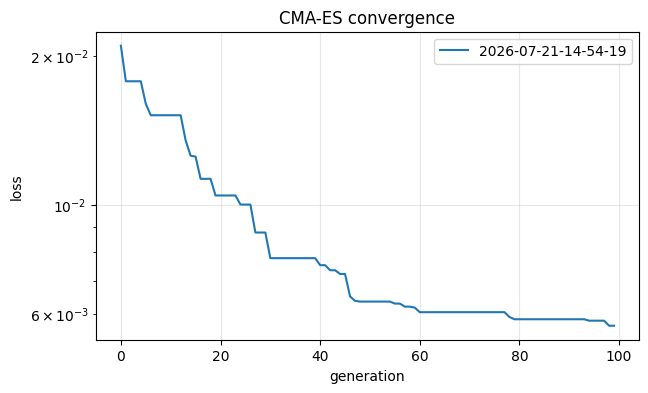

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for ts in RUNS:
    path = RESULTS / ts / "convergence.csv"
    if path.stat().st_size == 0:
        continue
    conv = pd.read_csv(path)
    ax.plot(conv["gen"], conv["loss"], label=ts)
ax.set(xlabel="generation", ylabel="loss", yscale="log", title="CMA-ES convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()